##Support Vector Machine on Bangla Sentiment


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Social Media Engagement Dataset.csv")
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,translated_text_content,hashtags,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকা...,#Food,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ...,"#MustHave, #Food",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী?...,"#Promo, #Food, #Trending",...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 4:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে ...,"#Reviews, #Sustainable",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো ল...,"#Health, #Travel",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [3]:
pd.set_option('display.max_colwidth', None)
selected_columns = ["text_content", "translated_text_content","sentiment_label"]
df = df[selected_columns]
df.head()

,text_content,translated_text_content,sentiment_label
0,Just tried the Chromebook from Google. Best purchase ever. #Food Really interested in hearing your thoughts!,গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকালের সেরা কেনাকাটা। #খাবার আপনার মতামত শুনতে সত্যিই আগ্রহী!,Positive
1,"Just saw an ad for Microsoft Surface Laptop during the SpringBlast2025. Not worth the money. #MustHave, #Food","স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম। টাকার মূল্য নেই। #অবশ্যই খাওয়া, #খাবার।",Negative
2,"What's your opinion about Nike's Epic React? #Promo, #Food, #Trending Really interested in hearing your thoughts!","নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী? #প্রচার, #খাবার, #ট্রেন্ডিং আপনার মতামত শুনতে সত্যিই আগ্রহী!",Negative
3,"Bummed out with my new Diet Pepsi from Pepsi! Disappointed with the quality. #Reviews, #Sustainable","পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে হতাশ। #পর্যালোচনা, #টেকসই",Negative
4,"Just tried the Corolla from Toyota. Absolutely loving it. #Health, #Travel Really interested in hearing your thoughts!","টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো লেগেছে। #স্বাস্থ্য, #ভ্রমণ আপনার মতামত শুনতে সত্যিই আগ্রহী!",Positive


In [4]:
df["sentiment_label"].value_counts()

,count
sentiment_label,
Negative,4854
Positive,4839
Neutral,2307


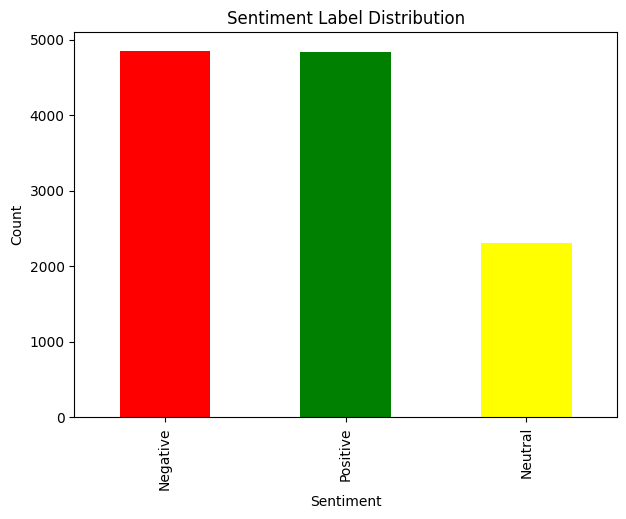

In [5]:
plt.figure(figsize=(7,5))
df['sentiment_label'].value_counts().plot(kind='bar', color=['red','green','yellow'])
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [6]:
df.isnull().sum()

,0
text_content,0
translated_text_content,0
sentiment_label,0


In [7]:
#Data Clean

import re
import unicodedata

def clean_bangla_text(text):

    if pd.isnull(text):
        return ""

    # 1. Normalize Unicode to ensure character consistency
    text = unicodedata.normalize('NFKC', str(text))

    # 2. Remove URLs and Social Media Mentions (@user)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\S+', '', text)

    # 3. Truncate at the first Hashtag
    # Based on dataset observation: everything from the first '#' onwards is noise
    if '#' in text:
        text = text.split('#')[0]

    # 4. Filter characters: Keep Bengali, English, Digits, and essential punctuation
    # Preserving punctuation like '।' and '.' helps BERT understand context
    text = re.sub(r'[^\u0980-\u09FFa-zA-Z0-9\s.,!?।]', ' ', text)

    # 5. Final whitespace normalization
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [8]:
df['clean_text'] =  df['translated_text_content'].apply(clean_bangla_text)
df['clean_text']

,clean_text
0,গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকালের সেরা কেনাকাটা।
1,স্প্রিংব্লাস্ট ২০২৫ এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম। টাকার মূল্য নেই।
2,নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী?
3,পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে হতাশ।
4,টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো লেগেছে।
...,...
11995,টয়োটা ক্যামেরির সাথে প্রতিযোগিতার তুলনা। সর্বকালের সেরা ক্রয়।
11996,অ্যাপল এয়ারপডস প্রো সম্পর্কে আমার দুই দিনের পর্যালোচনা অত্যন্ত সুপারিশ করছি।
11997,নাইকি থেকে আমার নতুন Dri FIT আনবক্স করলাম। সর্বকালের সেরা কেনাকাটা। রোমাঞ্চিত
11998,টয়োটা ক্যামেরিকে প্রতিযোগীদের সাথে তুলনা করা। কাজ করে।


In [9]:
from sklearn.model_selection import train_test_split

x = df['clean_text']
y = df['sentiment_label']

x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42)

print(f"Training set size: {len(x_train)}")
print(f"Validation set size: {len(x_valid)}")
print(f"Testing set size: {len(x_test)}")



Training set size: 8160
Validation set size: 1440
Testing set size: 2400


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(ngram_range=(1,3), max_features=(6000))

x_train_tfidf = tfidf.fit_transform(x_train)
x_valid_tfidf = tfidf.transform(x_valid)
x_test_tfidf = tfidf.transform(x_test)

print("Done!")

Done!


In [11]:
feature_names = tfidf.get_feature_names_out()

for word, score in zip(feature_names, x_train_tfidf[0].toarray()[0]):
    if score > 0:
        print(word, score)

অন 0.16724038367456284
অন আছ 0.32301631367839345
আছ 0.1519496292932847
আর 0.13177313482724007
আর থড 0.2206256523079933
আর থড অন 0.27913879110134193
গতক 0.1385187812352695
গতক পল 0.2370108892973216
গতক পল আর 0.35655627909275095
থড 0.2206256523079933
থড অন 0.27913879110134193
থড অন আছ 0.36845477117926284
পল 0.13710953905402065
পল আর 0.3186586168254011
পল আর থড 0.3397862963855722


In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)
y_test_encoded = label_encoder.transform(y_test)

print("After Label Encoding:", y_train_encoded[:5])
print("Before Label Encoding:\n", y_train[:5])

After Label Encoding: [1 0 0 2 2]
Before Label Encoding:
 5918     Neutral
6303    Negative
131     Negative
4436    Positive
8780    Positive
Name: sentiment_label, dtype: object


In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(x_train_tfidf, y_train_encoded)

y_pred_valid = svm_model.predict(x_valid_tfidf)

In [14]:
print("Accuracy:", accuracy_score(y_valid_encoded, y_pred_valid))
print("\nClassification Report:\n", classification_report(y_valid_encoded, y_pred_valid))
print("\nConfusion Matrix:\n", confusion_matrix(y_valid_encoded, y_pred_valid))

Accuracy: 0.9041666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.94      0.90       582
           1       0.95      0.74      0.83       277
           2       0.92      0.95      0.93       581

    accuracy                           0.90      1440
   macro avg       0.91      0.88      0.89      1440
weighted avg       0.91      0.90      0.90      1440


Confusion Matrix:
 [[545   7  30]
 [ 52 206  19]
 [ 26   4 551]]


In [15]:
train_pred = svm_model.predict(x_train_tfidf)
valid_pred = svm_model.predict(x_valid_tfidf)

from sklearn.metrics import accuracy_score

print("Train Accuracy:", accuracy_score(y_train_encoded, train_pred))
print("Validation Accuracy:", accuracy_score(y_valid_encoded, valid_pred))

Train Accuracy: 0.9280637254901961
Validation Accuracy: 0.9041666666666667


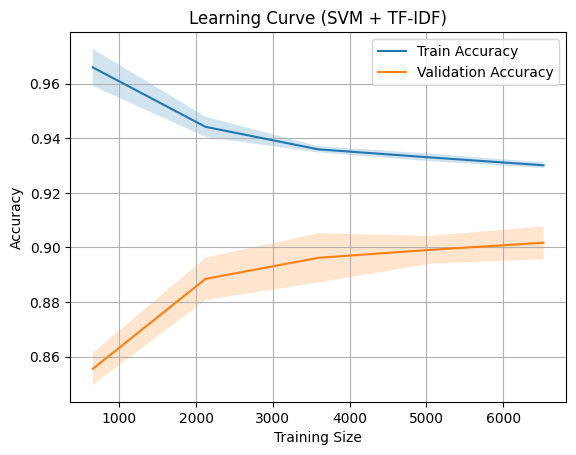

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    svm_model,
    x_train_tfidf,
    y_train_encoded,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Mean + std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plot
plt.plot(train_sizes, train_mean, label="Train Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")

# Shading (uncertainty area)
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.title("Learning Curve (SVM + TF-IDF)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()